In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))
sys.path.append(r"C:\Users\user\Desktop\MNE Playground\BrainBERT")


from utils.analysis_pipeline import (
    load_and_preprocess,
    create_epochs,
    save_epochs,
    plot_epochs_images
)
from utils.config import ch_to_keep
import models
import torch
from omegaconf import OmegaConf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%%capture out 
# %%capture out --no-stderr

files_list = {}
root = "../../PirogovDATA/"
for subject in ch_to_keep:
    # subject = "s09"
    if subject == 's01':
        continue
    files_list[subject] = load_and_preprocess(root, subject, autoclean = False)

In [ ]:
files_list['s15'] = load_and_preprocess(root, 's15', autoclean = False)

In [4]:
epochs_list = create_epochs(files_list, "s15", threshold= 15e-4)

Not setting metadata
113 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 113 events and 4601 original time points ...
    Rejecting  epoch based on EEG : ['Ft7']
    Rejecting  epoch based on EEG : ['F4', 'Ft7']
    Rejecting  epoch based on EEG : ['F4', 'Ft7']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Ft7', 'Fc3', 'Fcz', 'Fc4', 'Ft8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Ft7', 'Fc3', 'Fcz', 'Fc4', 'Ft8']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Ft7', 'Fc3', 'Fcz', 'Fc4', 'Ft8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Ft7', 'Fc3', 'Fcz', 'Fc4', 'Ft8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Ft7', 'Fc3', 'Fcz', 'Fc4', 'Ft8']
 

In [7]:
epochs_list[1]

{np.str_('LSL finger_flextion_index'): 1,
 np.str_('LSL finger_flextion_middle'): 2,
 np.str_('LSL finger_flextion_pinky'): 3,
 np.str_('LSL finger_flextion_ring'): 4,
 np.str_('LSL fist_clenching'): 5,
 np.str_('LSL index_middle_pinch'): 6,
 np.str_('LSL index_pinch'): 7,
 np.str_('LSL middle_pinch'): 8,
 np.str_('LSL open_hand'): 9,
 np.str_('LSL thumb_flextion'): 10,
 np.str_('State record'): 11}

Not setting metadata
8 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
8 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
8 matching events found
No baseline correction applied
0 projection items activated


C:\Users\user\AppData\Local\Temp\ipykernel_3412\2698063213.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs_list[0][1]["3"].plot_image(picks = ['Fp2','F8','Fcz'])
C:\Users\user\AppData\Local\Temp\ipykernel_3412\2698063213.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs_list[0][1]["3"].plot_image(picks = ['Fp2','F8','Fcz'])
C:\Users\user\AppData\Local\Temp\ipykernel_3412\2698063213.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs_list[0][1]["3"].plot_image(picks = ['Fp2','F8','Fcz'])


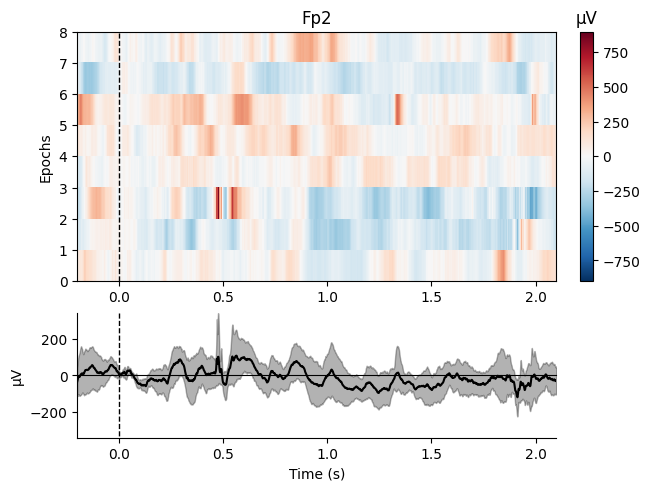

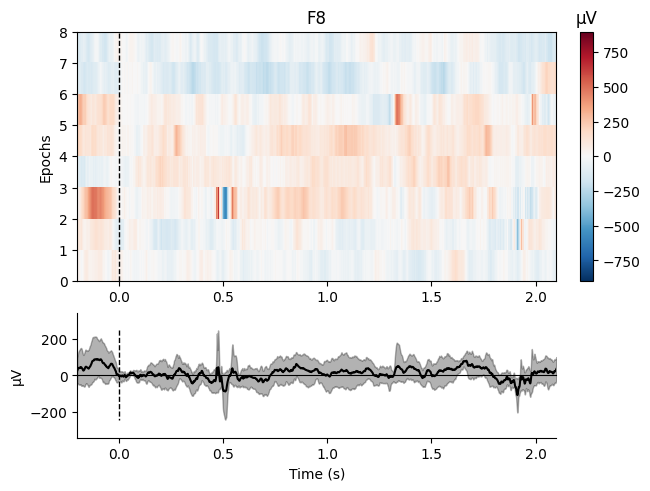

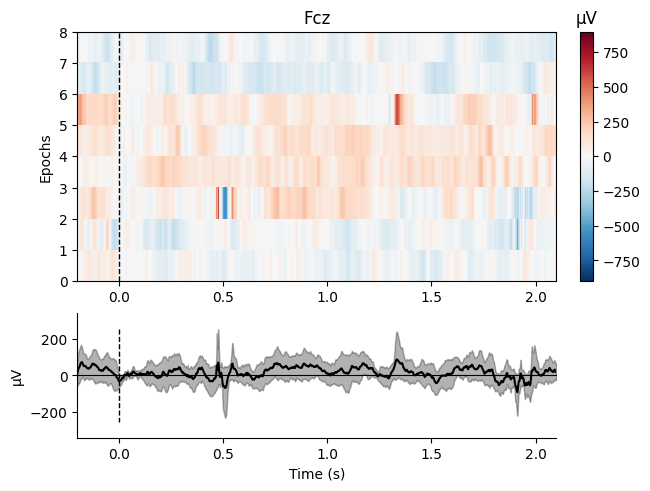

[<Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 3 Axes>]

In [13]:
epochs_list[0][1]["3"].plot_image(picks = ['Fp2','F8','Fcz'])

In [8]:
plot_epochs_images(epochs_list[0][1])

Not setting metadata
57 matching events found
No baseline correction applied
0 projection items activated


KeyboardInterrupt: 

In [7]:
import mne
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [8]:
freqs = np.linspace(0.1, 100, 50)   # frequencies of interest
n_cycles = freqs / 2. 
freqs

array([  0.1       ,   2.13877551,   4.17755102,   6.21632653,
         8.25510204,  10.29387755,  12.33265306,  14.37142857,
        16.41020408,  18.44897959,  20.4877551 ,  22.52653061,
        24.56530612,  26.60408163,  28.64285714,  30.68163265,
        32.72040816,  34.75918367,  36.79795918,  38.83673469,
        40.8755102 ,  42.91428571,  44.95306122,  46.99183673,
        49.03061224,  51.06938776,  53.10816327,  55.14693878,
        57.18571429,  59.2244898 ,  61.26326531,  63.30204082,
        65.34081633,  67.37959184,  69.41836735,  71.45714286,
        73.49591837,  75.53469388,  77.57346939,  79.6122449 ,
        81.65102041,  83.68979592,  85.72857143,  87.76734694,
        89.80612245,  91.84489796,  93.88367347,  95.92244898,
        97.96122449, 100.        ])

In [9]:
power = mne.time_frequency.tfr_morlet(
    epochs_list[1], freqs=freqs, n_cycles=n_cycles, return_itc=False, decim=2, average=False
)  # returns AverageTFR object

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


In [10]:
channels = epochs_list[1].ch_names  # choose subset of channels to keep plot small
states = list(epochs_list[1].event_id.keys())

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode

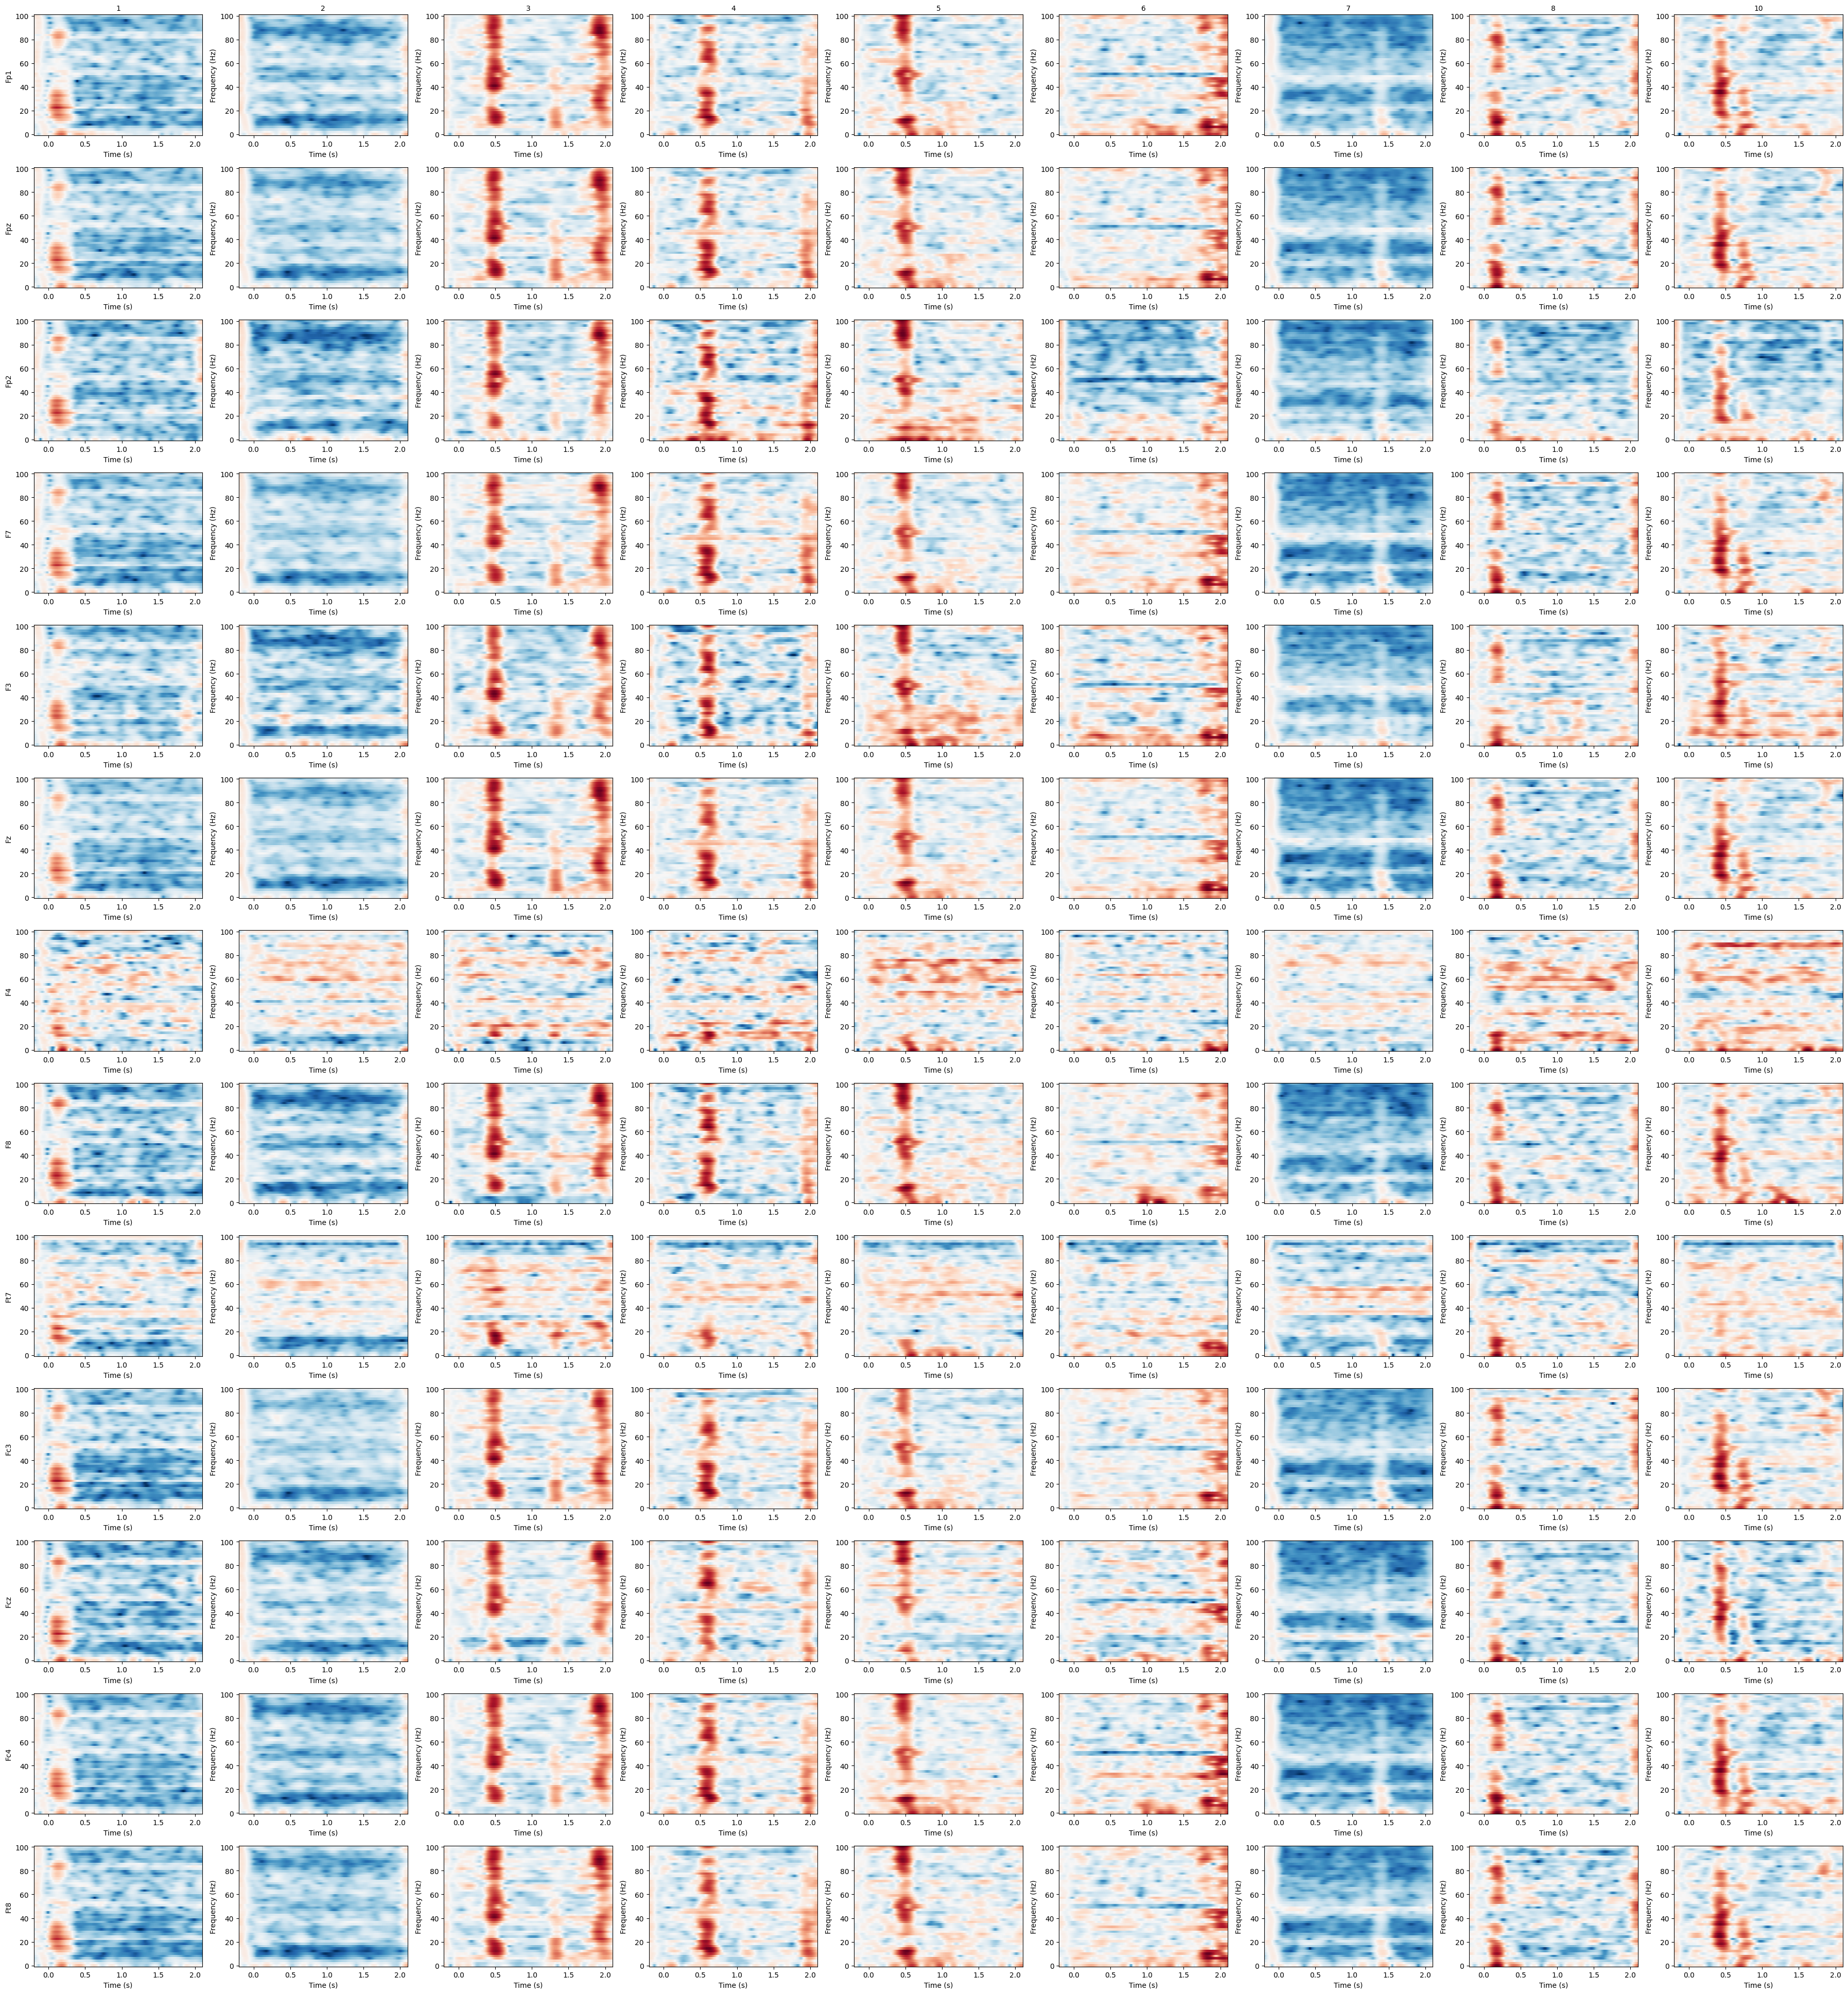

In [11]:
fig, axes = plt.subplots(len(channels), len(states),
                         figsize=(4*len(states), 3*len(channels)),
                         squeeze=False)

for i, ch in enumerate(channels):
    for j, state in enumerate(states):
        # select power for this condition
        power_cond = power[state].copy().pick(ch).average()

        # plot spectrogram into subplot
        power_cond.plot([0], baseline=(-0.3, 0), mode='logratio',
                        axes=axes[i, j], show=False, colorbar=False)

        if i == 0:
            axes[i, j].set_title(state, fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(ch)

plt.tight_layout()
plt.show()